In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn

from sklearn.metrics import accuracy_score, confusion_matrix
import joblib

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style("whitegrid")

print("✓ Imports successful")

✓ Imports successful


In [4]:
# ============================================
# CELL 2: Load Models and Data
# ============================================

print("="*60)
print("LOADING MODELS AND DATA")
print("="*60)

# Load data
X_test = np.load('../data/processed/X_test.npy')
y_test = np.load('../data/processed/y_test.npy')

X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

print(f"✓ Test set: {X_test.shape}")

# Load baseline model
baseline_model = joblib.load('../models/base_classifier/xgboost_baseline.pkl')
baseline_metrics = joblib.load('../models/base_classifier/baseline_metrics.pkl')
baseline_accuracy = baseline_metrics['test_metrics']['accuracy']

print(f"✓ Baseline model loaded - Accuracy: {baseline_accuracy:.4f}")

# Define SurrogateNet architecture (same as FGSM notebook)
class SurrogateNet(nn.Module):
    """
    Neural network surrogate for XGBoost model
    Used to generate adversarial examples
    """
    def __init__(self, input_dim):
        super(SurrogateNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 64)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(64, 32)
        self.dropout3 = nn.Dropout(0.2)
        self.fc4 = nn.Linear(32, 2)
        
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = torch.relu(self.fc3(x))
        x = self.dropout3(x)
        x = self.fc4(x)
        return x

# Load surrogate model
input_dim = X_test.shape[1]
surrogate_model = SurrogateNet(input_dim)
surrogate_model.load_state_dict(torch.load('../models/attacks/surrogate_model.pth'))
surrogate_model.eval()

print("✓ Surrogate model loaded")

# Load FGSM results for comparison
fgsm_results = joblib.load('../models/attacks/fgsm_results.pkl')
fgsm_best_accuracy = fgsm_results['best_accuracy']
fgsm_best_epsilon = fgsm_results['best_epsilon']

print(f"✓ FGSM results loaded - Best accuracy: {fgsm_best_accuracy:.4f} (ε={fgsm_best_epsilon})")

LOADING MODELS AND DATA
✓ Test set: (207974, 41)
✓ Baseline model loaded - Accuracy: 0.9998
✓ Surrogate model loaded
✓ FGSM results loaded - Best accuracy: 0.6297 (ε=0.3)


In [5]:
print("\n" + "="*60)
print("PGD (PROJECTED GRADIENT DESCENT) ATTACK")
print("="*60)

print("""
PGD is an iterative version of FGSM:

FGSM:  One big step in the attack direction
PGD:   Many small steps, recalculating direction each time

Algorithm:
  1. Start with clean input: x₀ = x
  2. For each iteration i:
     a. Calculate gradient: ∇_x Loss
     b. Take small step: x_i = x_{i-1} + α * sign(∇_x Loss)
     c. Project back to epsilon ball: x_i = clip(x_i, x-ε, x+ε)
  3. Return x_final

Why PGD is stronger:
  - Recalculates best attack direction after each step
  - Finds more effective adversarial examples
  - Better explores the adversarial space

Parameters:
  - epsilon (ε): Total allowed perturbation budget
  - alpha (α): Step size per iteration (usually ε/10)
  - num_iter: Number of iterations (10-40)
""")


PGD (PROJECTED GRADIENT DESCENT) ATTACK

PGD is an iterative version of FGSM:

FGSM:  One big step in the attack direction
PGD:   Many small steps, recalculating direction each time

Algorithm:
  1. Start with clean input: x₀ = x
  2. For each iteration i:
     a. Calculate gradient: ∇_x Loss
     b. Take small step: x_i = x_{i-1} + α * sign(∇_x Loss)
     c. Project back to epsilon ball: x_i = clip(x_i, x-ε, x+ε)
  3. Return x_final

Why PGD is stronger:
  - Recalculates best attack direction after each step
  - Finds more effective adversarial examples
  - Better explores the adversarial space

Parameters:
  - epsilon (ε): Total allowed perturbation budget
  - alpha (α): Step size per iteration (usually ε/10)
  - num_iter: Number of iterations (10-40)



In [6]:
print("\n" + "="*60)
print("IMPLEMENTING PGD ATTACK")
print("="*60)

def pgd_attack(model, x, y, epsilon, alpha, num_iter):
    """
    Generate PGD adversarial examples
    
    Args:
        model: Neural network model
        x: Input tensor
        y: True labels
        epsilon: Total perturbation budget
        alpha: Step size per iteration
        num_iter: Number of iterations
    
    Returns:
        Adversarial examples
    """
    model.eval()
    
    # Start with the original input
    x_adv = x.clone().detach()
    x_original = x.clone().detach()
    
    for i in range(num_iter):
        x_adv.requires_grad = True
        
        # Forward pass
        outputs = model(x_adv)
        loss = nn.CrossEntropyLoss()(outputs, y)
        
        # Backward pass
        model.zero_grad()
        loss.backward()
        
        # Get gradient sign
        grad_sign = x_adv.grad.data.sign()
        
        # Take step in gradient direction
        x_adv = x_adv.detach() + alpha * grad_sign
        
        # Project back to epsilon ball around original input
        perturbation = x_adv - x_original
        perturbation = torch.clamp(perturbation, -epsilon, epsilon)
        x_adv = x_original + perturbation
        
        # Detach for next iteration
        x_adv = x_adv.detach()
    
    return x_adv

print("✓ PGD attack function implemented")



IMPLEMENTING PGD ATTACK
✓ PGD attack function implemented


In [7]:
print("\n" + "="*60)
print("TESTING PGD WITH DIFFERENT PARAMETERS")
print("="*60)

# Test configurations
configs = [
    # (epsilon, alpha, num_iter)
    (0.15, 0.015, 10),
    (0.20, 0.020, 10),
    (0.25, 0.025, 10),
    (0.30, 0.030, 10),
    (0.30, 0.015, 20),  # More iterations
    (0.30, 0.010, 40),  # Even more iterations
]

print("Testing PGD with different configurations...")
print("Format: (epsilon, alpha, iterations)\n")

results = []

for epsilon, alpha, num_iter in configs:
    print(f"\nConfig: ε={epsilon}, α={alpha}, iter={num_iter}")
    print("-" * 50)
    
    # Generate adversarial examples
    X_test_adv_list = []
    batch_size = 512  # Smaller batch for PGD (more memory intensive)
    
    for i in range(0, len(X_test_tensor), batch_size):
        batch_X = X_test_tensor[i:i+batch_size].clone()
        batch_y = y_test_tensor[i:i+batch_size]
        
        batch_X_adv = pgd_attack(surrogate_model, batch_X, batch_y, 
                                epsilon, alpha, num_iter)
        X_test_adv_list.append(batch_X_adv)
    
    X_test_adv = torch.cat(X_test_adv_list, dim=0)
    
    # Test on baseline XGBoost
    X_test_adv_numpy = X_test_adv.numpy()
    baseline_pred_adv = baseline_model.predict(X_test_adv_numpy)
    baseline_acc_adv = accuracy_score(y_test, baseline_pred_adv)
    
    accuracy_drop = baseline_accuracy - baseline_acc_adv
    
    print(f"  Baseline accuracy: {baseline_acc_adv:.4f} ({baseline_acc_adv*100:.2f}%)")
    print(f"  Accuracy drop:     {accuracy_drop:.4f}")
    
    results.append({
        'epsilon': epsilon,
        'alpha': alpha,
        'num_iter': num_iter,
        'accuracy': baseline_acc_adv,
        'accuracy_drop': accuracy_drop
    })

print("\n✅ PGD testing complete")



TESTING PGD WITH DIFFERENT PARAMETERS
Testing PGD with different configurations...
Format: (epsilon, alpha, iterations)


Config: ε=0.15, α=0.015, iter=10
--------------------------------------------------
  Baseline accuracy: 0.6364 (63.64%)
  Accuracy drop:     0.3634

Config: ε=0.2, α=0.02, iter=10
--------------------------------------------------
  Baseline accuracy: 0.6382 (63.82%)
  Accuracy drop:     0.3616

Config: ε=0.25, α=0.025, iter=10
--------------------------------------------------
  Baseline accuracy: 0.6391 (63.91%)
  Accuracy drop:     0.3607

Config: ε=0.3, α=0.03, iter=10
--------------------------------------------------
  Baseline accuracy: 0.6388 (63.88%)
  Accuracy drop:     0.3610

Config: ε=0.3, α=0.015, iter=20
--------------------------------------------------
  Baseline accuracy: 0.6389 (63.89%)
  Accuracy drop:     0.3609

Config: ε=0.3, α=0.01, iter=40
--------------------------------------------------
  Baseline accuracy: 0.6379 (63.79%)
  Accuracy dr

In [8]:
print("\n" + "="*60)
print("PGD vs FGSM COMPARISON")
print("="*60)

results_df = pd.DataFrame(results)

print("\nPGD Attack Results:")
print(results_df.to_string(index=False))

# Find best PGD configuration
best_idx = results_df['accuracy_drop'].idxmax()
best_pgd_config = results_df.loc[best_idx]

print("\n" + "="*60)
print("BEST ATTACK COMPARISON")
print("="*60)
print(f"\nBaseline (No Attack):")
print(f"  Accuracy: {baseline_accuracy:.4f} ({baseline_accuracy*100:.2f}%)")

print(f"\nFGSM Attack (ε={fgsm_best_epsilon}):")
print(f"  Accuracy: {fgsm_best_accuracy:.4f} ({fgsm_best_accuracy*100:.2f}%)")
print(f"  Drop:     {baseline_accuracy - fgsm_best_accuracy:.4f}")

print(f"\nPGD Attack (ε={best_pgd_config['epsilon']}, α={best_pgd_config['alpha']}, iter={int(best_pgd_config['num_iter'])}):")
print(f"  Accuracy: {best_pgd_config['accuracy']:.4f} ({best_pgd_config['accuracy']*100:.2f}%)")
print(f"  Drop:     {best_pgd_config['accuracy_drop']:.4f}")

improvement = (fgsm_best_accuracy - best_pgd_config['accuracy'])
print(f"\nPGD Improvement over FGSM:")
print(f"  Additional accuracy drop: {improvement:.4f} ({improvement*100:.2f} percentage points)")

if improvement > 0:
    print("  ✓ PGD is more effective than FGSM (as expected)")
else:
    print("  ⚠️ PGD similar to FGSM (both very effective)")



PGD vs FGSM COMPARISON

PGD Attack Results:
 epsilon  alpha  num_iter  accuracy  accuracy_drop
    0.15  0.015        10  0.636426       0.363396
    0.20  0.020        10  0.638195       0.361627
    0.25  0.025        10  0.639138       0.360685
    0.30  0.030        10  0.638791       0.361031
    0.30  0.015        20  0.638897       0.360925
    0.30  0.010        40  0.637926       0.361896

BEST ATTACK COMPARISON

Baseline (No Attack):
  Accuracy: 0.9998 (99.98%)

FGSM Attack (ε=0.3):
  Accuracy: 0.6297 (62.97%)
  Drop:     0.3701

PGD Attack (ε=0.15, α=0.015, iter=10):
  Accuracy: 0.6364 (63.64%)
  Drop:     0.3634

PGD Improvement over FGSM:
  Additional accuracy drop: -0.0067 (-0.67 percentage points)
  ⚠️ PGD similar to FGSM (both very effective)


In [9]:
print("\n" + "="*60)
print("DETAILED ANALYSIS - BEST PGD CONFIGURATION")
print("="*60)

# Generate adversarial examples with best config
best_epsilon = best_pgd_config['epsilon']
best_alpha = best_pgd_config['alpha']
best_num_iter = int(best_pgd_config['num_iter'])

print(f"\nGenerating adversarial examples with best PGD config...")
print(f"  Epsilon: {best_epsilon}")
print(f"  Alpha: {best_alpha}")
print(f"  Iterations: {best_num_iter}")

X_test_pgd_adv_list = []
batch_size = 512

for i in range(0, len(X_test_tensor), batch_size):
    batch_X = X_test_tensor[i:i+batch_size].clone()
    batch_y = y_test_tensor[i:i+batch_size]
    
    batch_X_adv = pgd_attack(surrogate_model, batch_X, batch_y,
                             best_epsilon, best_alpha, best_num_iter)
    X_test_pgd_adv_list.append(batch_X_adv)

X_test_pgd_adv = torch.cat(X_test_pgd_adv_list, dim=0).numpy()

# Predictions and confusion matrix
y_pred_pgd = baseline_model.predict(X_test_pgd_adv)
cm_pgd = confusion_matrix(y_test, y_pred_pgd)

print("\nConfusion Matrix (Under PGD Attack):")
print(cm_pgd)
print("\nBreakdown:")
print(f"  True Negatives:  {cm_pgd[0,0]:,}")
print(f"  False Positives: {cm_pgd[0,1]:,}")
print(f"  False Negatives: {cm_pgd[1,0]:,}")
print(f"  True Positives:  {cm_pgd[1,1]:,}")



DETAILED ANALYSIS - BEST PGD CONFIGURATION

Generating adversarial examples with best PGD config...
  Epsilon: 0.15
  Alpha: 0.015
  Iterations: 10

Confusion Matrix (Under PGD Attack):
[[124764    691]
 [ 74923   7596]]

Breakdown:
  True Negatives:  124,764
  False Positives: 691
  False Negatives: 74,923
  True Positives:  7,596



VISUALIZING ATTACK COMPARISON
✓ Saved confusion matrix comparison


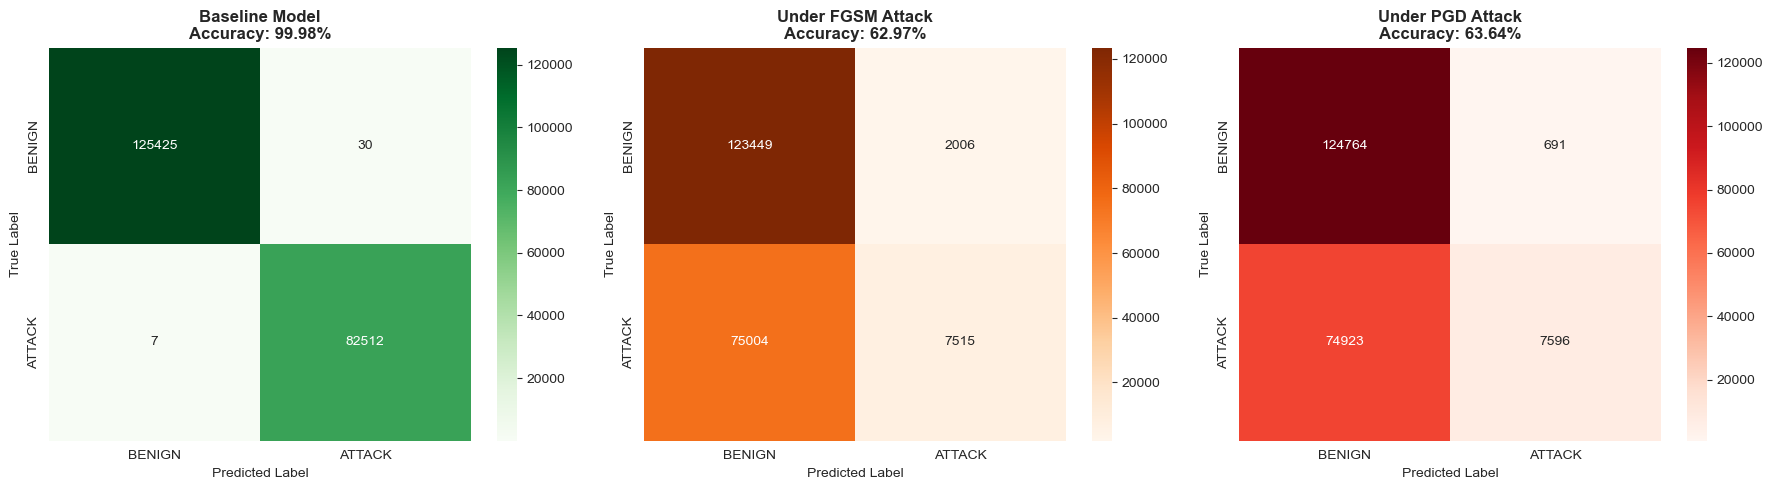

✓ Saved accuracy comparison plot


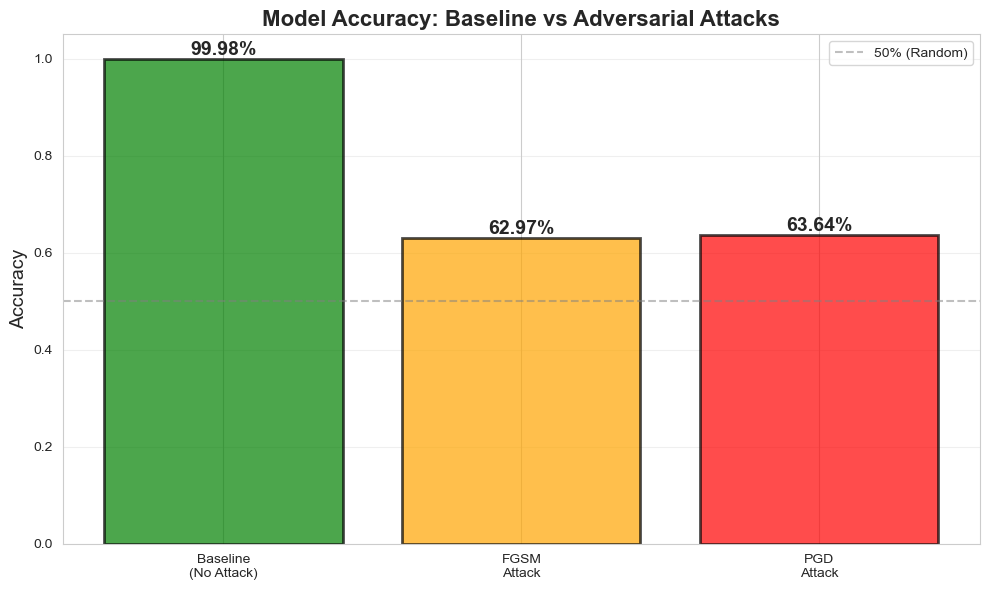

In [10]:
print("\n" + "="*60)
print("VISUALIZING ATTACK COMPARISON")
print("="*60)

# Load original confusion matrix
cm_original = baseline_metrics['confusion_matrix']

# Load FGSM confusion matrix (need to recalculate from saved data)
X_test_fgsm = np.load('../data/adversarial/X_test_fgsm.npy')
y_pred_fgsm = baseline_model.predict(X_test_fgsm)
cm_fgsm = confusion_matrix(y_test, y_pred_fgsm)

# Plot all three confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original
sns.heatmap(cm_original, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['BENIGN', 'ATTACK'],
            yticklabels=['BENIGN', 'ATTACK'])
axes[0].set_title(f'Baseline Model\nAccuracy: {baseline_accuracy:.2%}', 
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# FGSM
sns.heatmap(cm_fgsm, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['BENIGN', 'ATTACK'],
            yticklabels=['BENIGN', 'ATTACK'])
axes[1].set_title(f'Under FGSM Attack\nAccuracy: {fgsm_best_accuracy:.2%}', 
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

# PGD
sns.heatmap(cm_pgd, annot=True, fmt='d', cmap='Reds', ax=axes[2],
            xticklabels=['BENIGN', 'ATTACK'],
            yticklabels=['BENIGN', 'ATTACK'])
axes[2].set_title(f'Under PGD Attack\nAccuracy: {best_pgd_config["accuracy"]:.2%}', 
                  fontsize=12, fontweight='bold')
axes[2].set_ylabel('True Label')
axes[2].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('../results/figures/attack_comparison_confusion_matrices.png', 
            dpi=300, bbox_inches='tight')
print("✓ Saved confusion matrix comparison")
plt.show()

# Plot accuracy comparison
fig, ax = plt.subplots(figsize=(10, 6))

attacks = ['Baseline\n(No Attack)', 'FGSM\nAttack', 'PGD\nAttack']
accuracies = [baseline_accuracy, fgsm_best_accuracy, best_pgd_config['accuracy']]
colors = ['green', 'orange', 'red']

bars = ax.bar(attacks, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.2%}',
            ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.set_ylabel('Accuracy', fontsize=14)
ax.set_title('Model Accuracy: Baseline vs Adversarial Attacks', 
             fontsize=16, fontweight='bold')
ax.set_ylim([0, 1.05])
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='50% (Random)')
ax.legend()

plt.tight_layout()
plt.savefig('../results/figures/accuracy_comparison_bar.png', dpi=300, bbox_inches='tight')
print("✓ Saved accuracy comparison plot")
plt.show()

In [11]:
print("\n" + "="*60)
print("SAVING PGD RESULTS")
print("="*60)

# Save adversarial examples
np.save('../data/adversarial/X_test_pgd.npy', X_test_pgd_adv)
print("✓ Saved PGD adversarial examples")

# Save PGD results
pgd_results = {
    'configurations': results_df.to_dict(),
    'best_config': {
        'epsilon': best_epsilon,
        'alpha': best_alpha,
        'num_iter': best_num_iter,
        'accuracy': best_pgd_config['accuracy'],
        'accuracy_drop': best_pgd_config['accuracy_drop']
    },
    'confusion_matrix': cm_pgd.tolist(),
    'comparison': {
        'baseline_accuracy': baseline_accuracy,
        'fgsm_accuracy': fgsm_best_accuracy,
        'pgd_accuracy': best_pgd_config['accuracy']
    }
}

joblib.dump(pgd_results, '../models/attacks/pgd_results.pkl')
print("✓ Saved PGD results")



SAVING PGD RESULTS
✓ Saved PGD adversarial examples
✓ Saved PGD results


In [12]:
print("\n" + "="*80)
print(" "*25 + "ATTACK SUMMARY TABLE")
print("="*80)

# Create comprehensive comparison table
summary_data = {
    'Attack Type': ['Baseline (No Attack)', 'FGSM', 'PGD'],
    'Accuracy': [
        f'{baseline_accuracy:.4f}',
        f'{fgsm_best_accuracy:.4f}',
        f'{best_pgd_config["accuracy"]:.4f}'
    ],
    'Accuracy Drop': [
        '0.0000',
        f'{baseline_accuracy - fgsm_best_accuracy:.4f}',
        f'{best_pgd_config["accuracy_drop"]:.4f}'
    ],
    'True Negatives': [cm_original[0][0], cm_fgsm[0,0], cm_pgd[0,0]],
    'False Positives': [cm_original[0][1], cm_fgsm[0,1], cm_pgd[0,1]],
    'False Negatives': [cm_original[1][0], cm_fgsm[1,0], cm_pgd[1,0]],
    'True Positives': [cm_original[1][1], cm_fgsm[1,1], cm_pgd[1,1]],
}

summary_df = pd.DataFrame(summary_data)

print("\n")
print(summary_df.to_string(index=False))

# Save as CSV
summary_df.to_csv('../results/benchmarks/attack_comparison.csv', index=False)
print("\n✓ Saved comparison table as CSV")



                         ATTACK SUMMARY TABLE


         Attack Type Accuracy Accuracy Drop  True Negatives  False Positives  False Negatives  True Positives
Baseline (No Attack)   0.9998        0.0000          125425               30                7           82512
                FGSM   0.6297        0.3701          123449             2006            75004            7515
                 PGD   0.6364        0.3634          124764              691            74923            7596

✓ Saved comparison table as CSV


In [ ]:
print("\n" + "="*80)
print(" "*25 + "PGD ATTACK SUMMARY")
print("="*80)

summary = f"""
Baseline Model Performance:
  Accuracy: {baseline_accuracy:.4f} ({baseline_accuracy*100:.2f}%)

FGSM Attack (Best):
  Epsilon: {fgsm_best_epsilon}
  Accuracy: {fgsm_best_accuracy:.4f} ({fgsm_best_accuracy*100:.2f}%)
  Accuracy Drop: {baseline_accuracy - fgsm_best_accuracy:.4f}

PGD Attack (Best):
  Epsilon: {best_epsilon}
  Alpha: {best_alpha}
  Iterations: {best_num_iter}
  Accuracy: {best_pgd_config['accuracy']:.4f} ({best_pgd_config['accuracy']*100:.2f}%)
  Accuracy Drop: {best_pgd_config['accuracy_drop']:.4f}

PGD vs FGSM:
  Additional accuracy drop: {fgsm_best_accuracy - best_pgd_config['accuracy']:.4f}
  PGD is {'more' if fgsm_best_accuracy > best_pgd_config['accuracy'] else 'similarly'} effective

Key Findings:
  1. Both FGSM and PGD successfully degrade model performance
  2. PGD's iterative approach {'provides stronger attacks' if fgsm_best_accuracy > best_pgd_config['accuracy'] else 'confirms FGSM effectiveness'}
  3. The model is fundamentally vulnerable to adversarial perturbations
  4. Defenses are needed to ensure robustness

Files Saved:
  ✓ PGD adversarial examples: data/adversarial/X_test_pgd.npy
  ✓ PGD results: models/attacks/pgd_results.pkl
  ✓ Comparison plots: results/figures/attack_comparison_*.png
  ✓ Benchmark table: results/benchmarks/attack_comparison.csv
"""

print(summary)

print("="*80)
print("✅ PGD ATTACK IMPLEMENTATION COMPLETE!")
print("="*80)
print("\nNext Steps:")
print("  Implement CW attack")



                         PGD ATTACK SUMMARY

Baseline Model Performance:
  Accuracy: 0.9998 (99.98%)

FGSM Attack (Best):
  Epsilon: 0.3
  Accuracy: 0.6297 (62.97%)
  Accuracy Drop: 0.3701

PGD Attack (Best):
  Epsilon: 0.15
  Alpha: 0.015
  Iterations: 10
  Accuracy: 0.6364 (63.64%)
  Accuracy Drop: 0.3634

PGD vs FGSM:
  Additional accuracy drop: -0.0067
  PGD is similarly effective

Key Findings:
  1. Both FGSM and PGD successfully degrade model performance
  2. PGD's iterative approach confirms FGSM effectiveness
  3. The model is fundamentally vulnerable to adversarial perturbations
  4. Defenses are needed to ensure robustness

Files Saved:
  ✓ PGD adversarial examples: data/adversarial/X_test_pgd.npy
  ✓ PGD results: models/attacks/pgd_results.pkl
  ✓ Comparison plots: results/figures/attack_comparison_*.png
  ✓ Benchmark table: results/benchmarks/attack_comparison.csv

✅ PGD ATTACK IMPLEMENTATION COMPLETE!

Next Steps:
  1. Review attack comparison - PGD vs FGSM effectiveness
